# Notebook 2d — RF con CV por animal: Patrón de lesiones (3 clases)
### Tuberculosis bovina

Target: **Patron_lesiones_3** — -1=sin lesión, 0=localizado, 1=generalizado.
Evaluación con CV por animal (RepeatedStratifiedKFold) sin información de explotación.

## 1. Setup e importaciones

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import (RepeatedStratifiedKFold, StratifiedKFold,
                                     LeaveOneGroupOut)
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             average_precision_score, brier_score_loss,
                             matthews_corrcoef, recall_score)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import shap
import tb_utils as tb

PALETTE = tb.set_plot_style()
tb.set_seeds(tb.SEED)

import os

DATA = "../BD.csv"
df = tb.clean(tb.load_raw(DATA))

d = tb.target_subset(df, "Patron_lesiones_3")
d = tb.drop_sparse_rows(d)

# Features: SOLO biomarcadores — sin ninguna variable de explotación
X_all = d[tb.MODEL_FEATURES].copy()
y     = d["Patron_lesiones_3"].astype(int).values   # clases {-1, 0, 1}

print(f"Dataset: n={len(y)}")
print(f"Features ({len(tb.MODEL_FEATURES)}): {tb.MODEL_FEATURES}")
print("Distribución de clases:")
print(pd.Series(y).value_counts().sort_index())
print("Balanced acc. azar (3 clases) = 0.333")
print(f"\nNota: la variable explotación (granja) se IGNORA completamente.")
print(f"CV splits cruzan granjas libremente → estimación optimista.")

drop_sparse_rows: 3 fila(s) eliminada(s) (>4 NaN en features). n restante = 103.
Dataset: n=103
Features (8): ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log', 'EDAD', 'PIROPLASMA', 'THEILERIA', 'ANAPLASMA', 'RAZA2']
Distribución de clases:
-1    40
 0    40
 1    23
Name: count, dtype: int64
Balanced acc. azar (3 clases) = 0.333

Nota: la variable explotación (granja) se IGNORA completamente.
CV splits cruzan granjas libremente → estimación optimista.


## 2. Random Forest y estrategia de validación cruzada

**CV por animal sin explotación (RepeatedStratifiedKFold, 5×10):**
- Estratificado solo por `y` (balance de clases) — funciona bien con 3 clases discretas.
- La variable explotación **no existe** en ninguna parte del pipeline.
- Dado que animales de la misma granja pueden estar simultáneamente en train y test,
  y la granja es un fuerte confundidor, esta estimación es **optimista** respecto al
  verdadero rendimiento en nuevas granjas.
- Su valor es revelar la señal máxima extraíble de los biomarcadores bajo el supuesto
  (no verificado) de independencia entre animales de distintas granjas.

In [2]:
def make_rf(n_estimators=100, min_samples_leaf=5):
    return RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=None,
        min_samples_leaf=min_samples_leaf,
        max_features="sqrt",
        class_weight="balanced",
        random_state=tb.SEED,
        n_jobs=-1,
        oob_score=True,
    )

def make_pipe_d(feature_list, n_estimators=100):
    """Pipeline sin escalado, sin explotación."""
    num_f = [f for f in feature_list if f in tb.NUM_FEATURES]
    cat_f = [f for f in feature_list if f in tb.CAT_FEATURES]
    prep  = tb.make_preprocessor(numeric=num_f, categorical=cat_f, scale=False)
    return Pipeline([("prep", prep), ("clf", make_rf(n_estimators=n_estimators))])

CV_OUTER = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=tb.SEED)

def cv_animal_metrics_d(feature_list, X, y, cv=None, detailed=False, n_estimators=100):
    """Balanced accuracy y ROC-AUC macro con CV por animal (sin explotación)."""
    if cv is None:
        cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=tb.SEED)
    Xs = X[list(feature_list)]
    pipe_tmpl = make_pipe_d(feature_list, n_estimators)
    rows = []
    for tr, te in cv.split(Xs, y):
        if len(np.unique(y[te])) < 2:
            continue
        pf = clone(pipe_tmpl)
        pf.fit(Xs.iloc[tr], y[tr])
        p    = pf.predict_proba(Xs.iloc[te])
        pred = pf.predict(Xs.iloc[te])
        bal  = balanced_accuracy_score(y[te], pred)
        try:
            roc = roc_auc_score(y[te], p, multi_class='ovr', average='macro')
        except Exception:
            roc = np.nan
        rows.append(dict(bal_acc=bal, roc_mac=roc))
    df_r = pd.DataFrame(rows)
    if detailed:
        return df_r
    return df_r.bal_acc.mean(), df_r.bal_acc.std()

# Evaluación baseline
print("Evaluación baseline RF (todos los features de biomarcadores, CV por animal):")
base_m, base_s = cv_animal_metrics_d(tb.MODEL_FEATURES, X_all, y)
print(f"  BAL_ACC = {base_m:.3f} ± {base_s:.3f}")
print(f"  Balanced acc. azar (3 clases) = 0.333")

Evaluación baseline RF (todos los features de biomarcadores, CV por animal):
  BAL_ACC = 0.379 ± 0.108
  Balanced acc. azar (3 clases) = 0.333


## 3. Pipeline de selección de características

Mismo algoritmo que Notebooks 2 y 2b/2c, usando **CV por animal sin explotación**:
1. Importancia de permutación sobre modelo completo (en muestra) → ranking.
2. Eliminación hacia atrás, calculando Balanced Accuracy CV por animal en cada paso.
3. Selección: subconjunto más pequeño con BAL_ACC ≥ máx − 1·DE.

Paso 1: Ajustando RF completo para ranking de importancia...
OOB Score (en muestra): 0.359

Ranking importancia de permutación (sin explotación):
                 pretty  imp_mean  imp_std
             Vitamina D    0.1722   0.0334
log(1+Carga piroplasma)    0.1350   0.0315
                 Calcio    0.1102   0.0253
            Edad (años)    0.0888   0.0294
                   Raza    0.0649   0.0185
     Theileria spp. (+)    0.0290   0.0158
     Anaplasma spp. (+)    0.0278   0.0161
         Piroplasma (+)    0.0070   0.0031


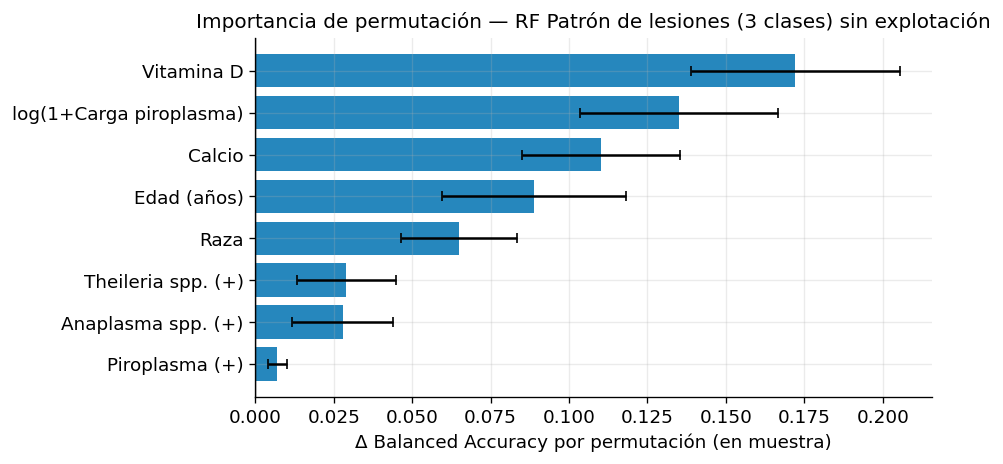

In [3]:
print("Paso 1: Ajustando RF completo para ranking de importancia...")
full_pipe = make_pipe_d(tb.MODEL_FEATURES).fit(X_all, y)
print(f"OOB Score (en muestra): {full_pipe.named_steps['clf'].oob_score_:.3f}")

pi = permutation_importance(
    full_pipe, X_all, y,
    scoring="balanced_accuracy",
    n_repeats=50,
    random_state=tb.SEED,
    n_jobs=-1,
)
imp_df = pd.DataFrame({
    "feature":  tb.MODEL_FEATURES,
    "imp_mean": pi.importances_mean,
    "imp_std":  pi.importances_std,
}).sort_values("imp_mean", ascending=False).reset_index(drop=True)
imp_df["pretty"] = imp_df.feature.map(lambda f: tb.PRETTY.get(f, f))

print("\nRanking importancia de permutación (sin explotación):")
print(imp_df[["pretty", "imp_mean", "imp_std"]].round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
order = imp_df.sort_values("imp_mean")
ax.barh(order.pretty, order.imp_mean, xerr=order.imp_std, color=PALETTE[0], capsize=3, alpha=0.85)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ Balanced Accuracy por permutación (en muestra)")
ax.set_title("Importancia de permutación — RF Patrón de lesiones (3 clases) sin explotación")
plt.tight_layout(); plt.savefig("figures/fig_2d_perm_importance_full.png"); plt.show()

In [4]:
CV_SEL = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=tb.SEED)
elim_order = imp_df.sort_values("imp_mean", ascending=True)["feature"].tolist()
print(f"Orden de eliminación: {elim_order}\n")
print("Paso 2: Eliminación hacia atrás (CV por animal, puede tardar 1-2 min)...\n")

current_features = tb.MODEL_FEATURES.copy()
history = []

m0, s0 = cv_animal_metrics_d(current_features, X_all, y, cv=CV_SEL)
history.append({"n": len(current_features), "features": current_features.copy(),
                "removed": "—(baseline)", "mean": m0, "std": s0})
print(f"  {len(current_features):2d} features [baseline] BAL_ACC={m0:.3f}±{s0:.3f}")

for feat in elim_order:
    if feat not in current_features or len(current_features) <= 1:
        break
    test_feats = [f for f in current_features if f != feat]
    m, s = cv_animal_metrics_d(test_feats, X_all, y, cv=CV_SEL)
    history.append({"n": len(test_feats), "features": test_feats.copy(),
                    "removed": feat, "mean": m, "std": s})
    print(f"  {len(test_feats):2d} features [-{feat:20s}] BAL_ACC={m:.3f}±{s:.3f}  Δ={m-m0:+.3f}")
    current_features = test_feats

hist_df = pd.DataFrame(history)

Orden de eliminación: ['PIROPLASMA', 'ANAPLASMA', 'THEILERIA', 'RAZA2', 'EDAD', 'CALCIO', 'PIROPLASMA_Q_log', 'VITAMINA_D']

Paso 2: Eliminación hacia atrás (CV por animal, puede tardar 1-2 min)...

   8 features [baseline] BAL_ACC=0.399±0.096
   7 features [-PIROPLASMA          ] BAL_ACC=0.363±0.079  Δ=-0.036
   6 features [-ANAPLASMA           ] BAL_ACC=0.390±0.095  Δ=-0.009
   5 features [-THEILERIA           ] BAL_ACC=0.379±0.118  Δ=-0.020
   4 features [-RAZA2               ] BAL_ACC=0.402±0.100  Δ=+0.003
   3 features [-EDAD                ] BAL_ACC=0.393±0.103  Δ=-0.006
   2 features [-CALCIO              ] BAL_ACC=0.431±0.110  Δ=+0.032
   1 features [-PIROPLASMA_Q_log    ] BAL_ACC=0.376±0.109  Δ=-0.023


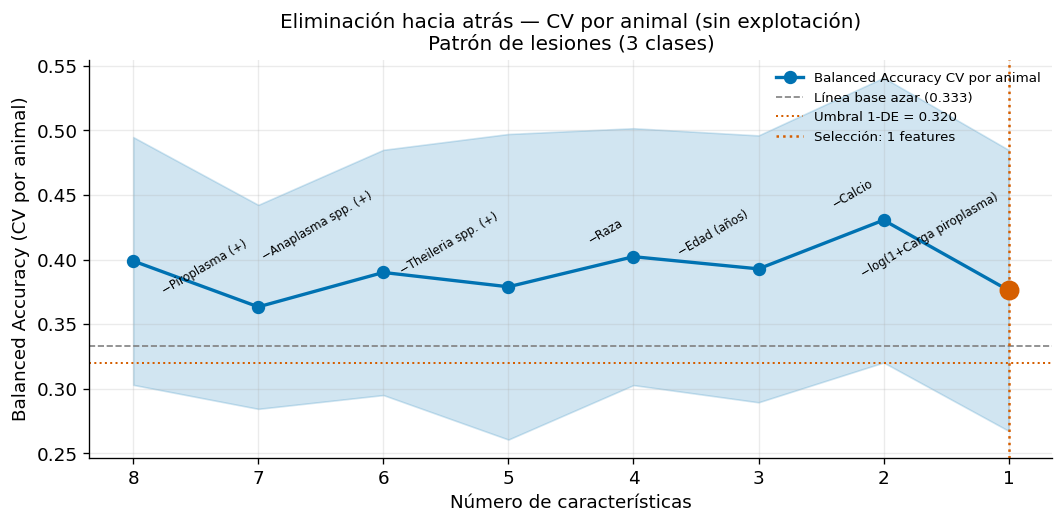


Features SELECCIONADOS (1): ['VITAMINA_D']


In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(hist_df.n, hist_df["mean"], "o-", color=PALETTE[0], lw=2, ms=7, label="Balanced Accuracy CV por animal")
ax.fill_between(hist_df.n,
                hist_df["mean"] - hist_df["std"],
                hist_df["mean"] + hist_df["std"], alpha=0.18, color=PALETTE[0])
ax.axhline(1/3, ls="--", color="grey", lw=1, label="Línea base azar (0.333)")

best_idx     = hist_df["mean"].idxmax()
best_mu      = hist_df["mean"].max()
best_sd      = hist_df.loc[best_idx, "std"]
threshold    = best_mu - best_sd
parsimonious = hist_df[hist_df["mean"] >= threshold].sort_values("n").iloc[0]

ax.axhline(threshold, ls=":", color=PALETTE[1], lw=1.2, label=f"Umbral 1-DE = {threshold:.3f}")
ax.axvline(parsimonious.n, color=PALETTE[1], ls=":", lw=1.5,
           label=f"Selección: {int(parsimonious.n)} features")
ax.scatter([parsimonious.n], [parsimonious["mean"]], color=PALETTE[1], s=120, zorder=5)

for _, row in hist_df.iterrows():
    label = tb.PRETTY.get(row.removed, row.removed) if row.removed != "—(baseline)" else ""
    if label:
        ax.annotate(f"−{label}", (row.n, row["mean"]),
                    textcoords="offset points", xytext=(-5, 8),
                    fontsize=7, ha="right", rotation=30)

ax.set_xlabel("Número de características")
ax.set_ylabel("Balanced Accuracy (CV por animal)")
ax.set_title("Eliminación hacia atrás — CV por animal (sin explotación)\nPatrón de lesiones (3 clases)")
ax.legend(fontsize=8); ax.invert_xaxis()
plt.tight_layout(); plt.savefig("figures/fig_2d_feature_selection_curve.png"); plt.show()

SELECTED_D = list(parsimonious.features)
print(f"\nFeatures SELECCIONADOS ({len(SELECTED_D)}): {SELECTED_D}")

In [6]:
print("Calculando ROC-AUC macro para cada subconjunto de hist_df (≈1 min)...")
roc_means, roc_stds = [], []
for _, row in hist_df.iterrows():
    Xs_tmp = X_all[list(row["features"])]
    pipe_tmpl = make_pipe_d(row["features"])
    rocs = []
    for tr, te in CV_SEL.split(Xs_tmp, y):
        if len(np.unique(y[te])) < 2:
            continue
        pf = clone(pipe_tmpl)
        pf.fit(Xs_tmp.iloc[tr], y[tr])
        p = pf.predict_proba(Xs_tmp.iloc[te])
        try:
            rocs.append(roc_auc_score(y[te], p, multi_class='ovr', average='macro'))
        except Exception:
            rocs.append(np.nan)
    roc_means.append(np.nanmean(rocs))
    roc_stds.append(np.nanstd(rocs))
    print(f"  {int(row.n):2d} features [-{row['removed']:20s}] ROC={roc_means[-1]:.3f}±{roc_stds[-1]:.3f}")

hist_df = hist_df.assign(roc_mean=roc_means, roc_std=roc_stds)
print("\nhist_df actualizado con columnas roc_mean / roc_std.")

Calculando ROC-AUC macro para cada subconjunto de hist_df (≈1 min)...
   8 features [-—(baseline)         ] ROC=0.544±0.075
   7 features [-PIROPLASMA          ] ROC=0.546±0.076
   6 features [-ANAPLASMA           ] ROC=0.545±0.079
   5 features [-THEILERIA           ] ROC=0.566±0.072
   4 features [-RAZA2               ] ROC=0.557±0.083
   3 features [-EDAD                ] ROC=0.544±0.082
   2 features [-CALCIO              ] ROC=0.567±0.080
   1 features [-PIROPLASMA_Q_log    ] ROC=0.550±0.058

hist_df actualizado con columnas roc_mean / roc_std.


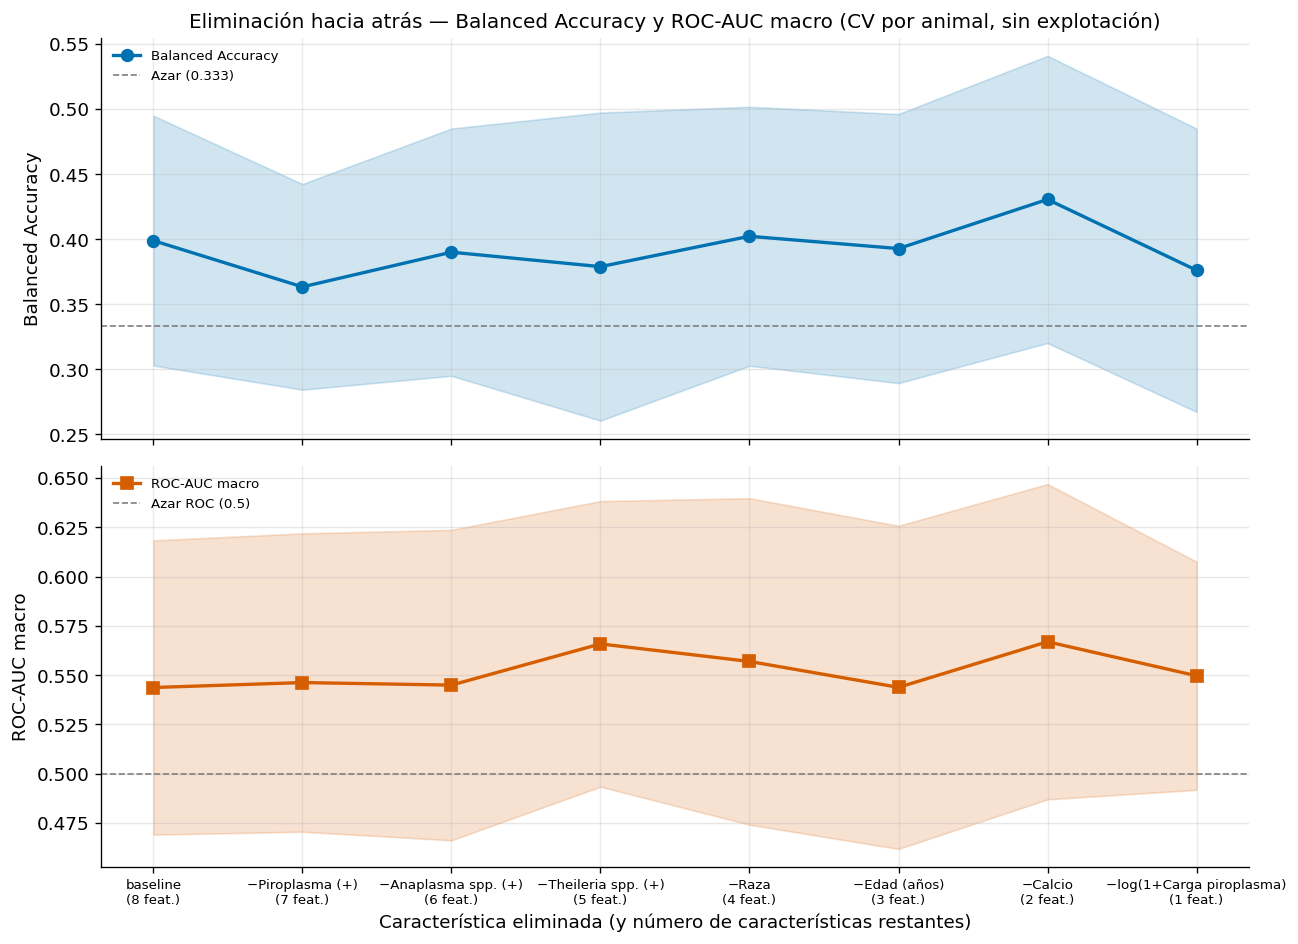

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

x      = np.arange(len(hist_df))
labels = []
for _, row in hist_df.iterrows():
    if row["removed"] == "—(baseline)":
        lbl = f"baseline\n({int(row.n)} feat.)"
    else:
        pretty = tb.PRETTY.get(row["removed"], row["removed"])
        lbl = f"−{pretty}\n({int(row.n)} feat.)"
    labels.append(lbl)

# --- Balanced Accuracy ---
ax1 = axes[0]
ax1.plot(x, hist_df["mean"], "o-", color=PALETTE[0], lw=2, ms=7, label="Balanced Accuracy")
ax1.fill_between(x,
                 hist_df["mean"] - hist_df["std"],
                 hist_df["mean"] + hist_df["std"],
                 alpha=0.18, color=PALETTE[0])
ax1.axhline(1/3, ls="--", color="grey", lw=1, label="Azar (0.333)")
ax1.set_ylabel("Balanced Accuracy")
ax1.legend(fontsize=8)
ax1.set_title("Eliminación hacia atrás — Balanced Accuracy y ROC-AUC macro (CV por animal, sin explotación)")
ax1.grid(axis="y", alpha=0.3)

# --- ROC-AUC macro ---
ax2 = axes[1]
ax2.plot(x, hist_df["roc_mean"], "s-", color=PALETTE[1], lw=2, ms=7, label="ROC-AUC macro")
ax2.fill_between(x,
                 hist_df["roc_mean"] - hist_df["roc_std"],
                 hist_df["roc_mean"] + hist_df["roc_std"],
                 alpha=0.18, color=PALETTE[1])
ax2.axhline(0.5, ls="--", color="grey", lw=1, label="Azar ROC (0.5)")
ax2.set_ylabel("ROC-AUC macro")
ax2.legend(fontsize=8)
ax2.grid(axis="y", alpha=0.3)

ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=8, ha="center")
ax2.set_xlabel("Característica eliminada (y número de características restantes)")

plt.tight_layout()
plt.savefig("figures/fig_2d_feature_selection_metrics.png", bbox_inches="tight")
plt.show()

## 4. Evaluación del modelo final (CV por animal, 5×10)

In [8]:
print(X_all.columns)

Index(['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log', 'EDAD', 'PIROPLASMA',
       'THEILERIA', 'ANAPLASMA', 'RAZA2'],
      dtype='str')


In [9]:
SELECTED_D = ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log']
Xs = X_all[SELECTED_D].copy()
print(f"Features seleccionados ({len(SELECTED_D)}): {SELECTED_D}\n")


Features seleccionados (3): ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log']



Métricas CV por animal (5×10, sin explotación):
  BAL_ACC  = 0.407 ± 0.104   (azar = 0.333)
  ROC mac  = 0.548 ± 0.103   (azar = 0.5)


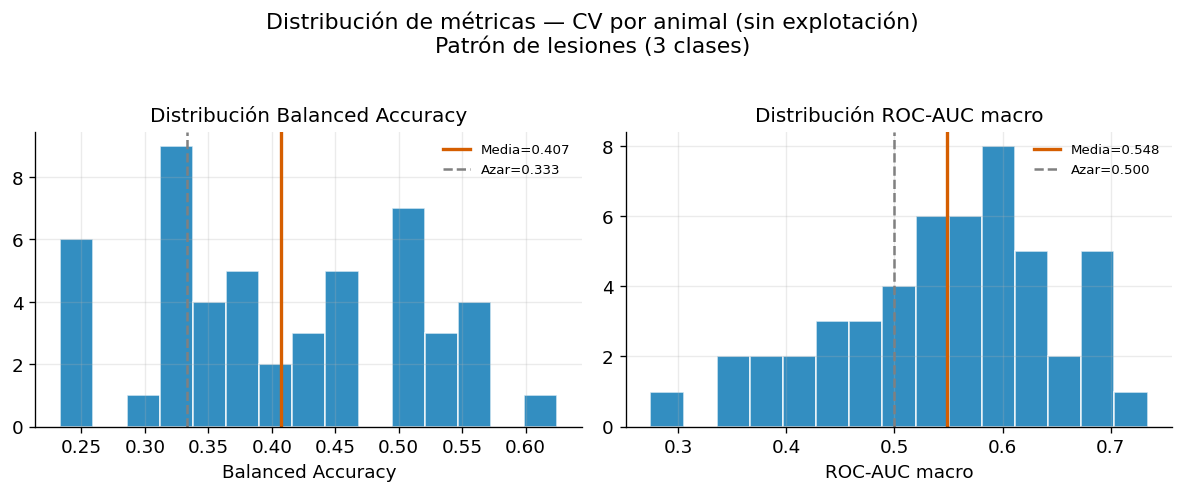

In [10]:
detailed_df = cv_animal_metrics_d(SELECTED_D, X_all, y, cv=CV_OUTER, detailed=True, n_estimators=700)
m = detailed_df.mean(); s = detailed_df.std()

print("Métricas CV por animal (5×10, sin explotación):")
print(f"  BAL_ACC  = {m.bal_acc:.3f} ± {s.bal_acc:.3f}   (azar = 0.333)")
print(f"  ROC mac  = {m.roc_mac:.3f} ± {s.roc_mac:.3f}   (azar = 0.5)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, title, chance in zip(axes,
                                   ["bal_acc", "roc_mac"],
                                   ["Balanced Accuracy", "ROC-AUC macro"],
                                   [1/3, 0.5]):
    ax.hist(detailed_df[col].dropna(), bins=15, color=PALETTE[0], alpha=0.8, edgecolor="white")
    ax.axvline(detailed_df[col].mean(), color=PALETTE[1], lw=2,
               label=f"Media={detailed_df[col].mean():.3f}")
    ax.axvline(chance, color="grey", ls="--", lw=1.5, label=f"Azar={chance:.3f}")
    ax.set_xlabel(title); ax.set_title(f"Distribución {title}"); ax.legend(fontsize=8)
plt.suptitle("Distribución de métricas — CV por animal (sin explotación)\nPatrón de lesiones (3 clases)", y=1.02)
plt.tight_layout(); plt.savefig("figures/fig_2d_metrics_dist.png", bbox_inches="tight"); plt.show()


## 5. Interpretabilidad global — SHAP

Este análisis muestra la importancia de los biomarcadores **en ausencia de información
de granja**. Se calcula SHAP para las 3 clases y se visualiza especialmente la clase
**generalizado** (clase 1), que representa el mayor grado de severidad lesional.

In [11]:
print(SELECTED_D)

['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log']


In [12]:
FINAL_D = make_pipe_d(SELECTED_D, n_estimators=500).fit(Xs, y)
print(f"OOB Score (en muestra): {FINAL_D.named_steps['clf'].oob_score_:.3f}")

prep_d  = FINAL_D.named_steps["prep"]
clf_d   = FINAL_D.named_steps["clf"]
Xt_d    = prep_d.transform(Xs)
names_d = list(prep_d.get_feature_names_out())

explainer_d = shap.TreeExplainer(clf_d)
shap_vals_d = explainer_d.shap_values(Xt_d)

# Normalizar: SHAP nuevo → 3D array (n, features, n_classes)
if isinstance(shap_vals_d, list):
    sv_d_list = shap_vals_d            # lista de arrays por clase
    sv_d_mean = np.mean([np.abs(s) for s in sv_d_list], axis=0)  # mean |shap| por clase
else:
    arr = np.asarray(shap_vals_d)
    if arr.ndim == 3:
        sv_d_list = [arr[:, :, i] for i in range(arr.shape[2])]
        sv_d_mean = np.abs(arr).mean(axis=2)
    else:
        sv_d_list = [arr]
        sv_d_mean = np.abs(arr)

# Para clase generalizado (índice 2 en clases ordenadas -1, 0, 1)
classes_sorted = np.sort(np.unique(y))
idx_gen = np.where(classes_sorted == 1)[0][0]   # índice de la clase 1 (generalizado)
sv_d_gen = sv_d_list[idx_gen]

exp_val_d = (float(explainer_d.expected_value[idx_gen])
             if isinstance(explainer_d.expected_value, (list, np.ndarray))
             else float(explainer_d.expected_value))

print(f"Features tras preprocesamiento : {names_d}")
print(f"Clases ordenadas               : {classes_sorted}")
print(f"Índice clase generalizado      : {idx_gen}")
print(f"SHAP values generalizado shape : {sv_d_gen.shape}")
print(f"Expected value (clase generalizado): {exp_val_d:.4f}")

OOB Score (en muestra): 0.408
Features tras preprocesamiento : ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log']
Clases ordenadas               : [-1  0  1]
Índice clase generalizado      : 2
SHAP values generalizado shape : (103, 3)
Expected value (clase generalizado): 0.3312


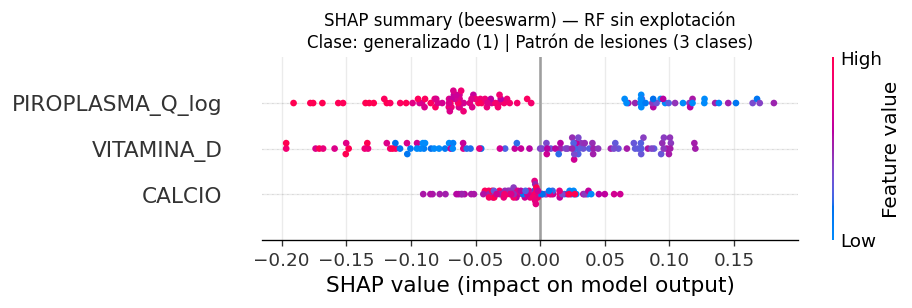

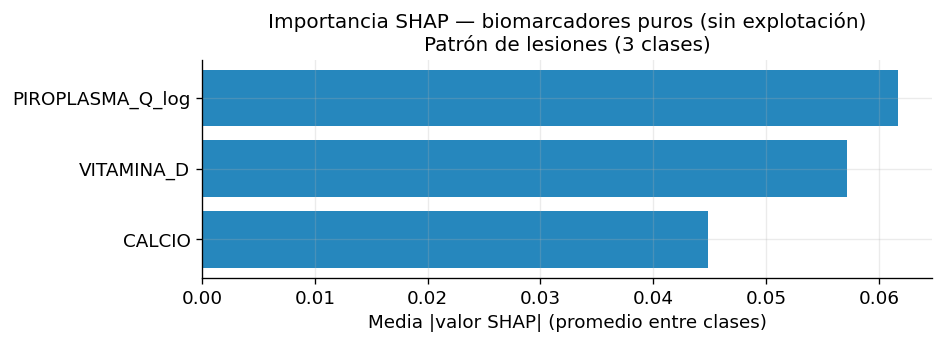

In [13]:
# Beeswarm para clase generalizado
plt.figure(figsize=(9, max(4, 0.5 * len(names_d))))
shap.summary_plot(sv_d_gen, Xt_d, feature_names=names_d, show=False, max_display=len(names_d))
plt.title("SHAP summary (beeswarm) — RF sin explotación\n"
          "Clase: generalizado (1) | Patrón de lesiones (3 clases)", fontsize=10)
plt.tight_layout(); plt.savefig("figures/fig_2d_shap_summary.png", bbox_inches="tight"); plt.show()

# Importancia media |SHAP| entre clases
mean_abs_d = sv_d_mean.mean(0)
si_d = pd.DataFrame({"feature": names_d, "mean_abs": mean_abs_d}).sort_values("mean_abs")
fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(names_d))))
ax.barh(si_d.feature, si_d.mean_abs, color=PALETTE[0], alpha=0.85)
ax.set_xlabel("Media |valor SHAP| (promedio entre clases)")
ax.set_title("Importancia SHAP — biomarcadores puros (sin explotación)\nPatrón de lesiones (3 clases)")
plt.tight_layout(); plt.savefig("figures/fig_2d_shap_importance.png"); plt.show()

In [14]:
# Force plot global: todos los animales ordenados por probabilidad predicha (clase generalizado)
shap.initjs()

order = np.argsort(FINAL_D.predict_proba(Xs)[:, idx_gen])
fp = shap.force_plot(
    exp_val_d,
    sv_d_gen[order],
    Xt_d[order],
    feature_names=names_d,
)
shap.save_html("figures/fig_2d_shap_force_plot_global.html", fp)
display(fp)

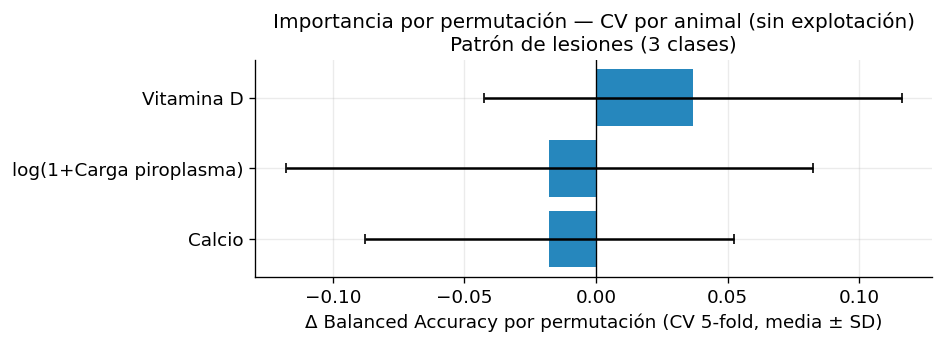

Estabilidad Spearman entre folds: 0.400


In [15]:
# Importancia por permutación — estabilidad
imp_runs_d = []
cv_stab = StratifiedKFold(n_splits=5, shuffle=True, random_state=tb.SEED)
for tr, te in cv_stab.split(Xs, y):
    if len(np.unique(y[te])) < 2: continue
    pf = clone(make_pipe_d(SELECTED_D)).fit(Xs.iloc[tr], y[tr])
    pi_f = permutation_importance(pf, Xs.iloc[te], y[te],
                                  scoring="balanced_accuracy", n_repeats=20,
                                  random_state=tb.SEED)
    imp_runs_d.append(pd.Series(pi_f.importances_mean, index=SELECTED_D))

imp_mat_d = pd.concat(imp_runs_d, axis=1)
imp_ord_d = imp_mat_d.mean(axis=1).sort_values().index

from scipy.stats import spearmanr
R = imp_mat_d.fillna(0)
cors = [spearmanr(R.iloc[:,i], R.iloc[:,j]).correlation
        for i in range(R.shape[1]) for j in range(i+1, R.shape[1])]

fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(SELECTED_D))))
ax.barh([tb.PRETTY.get(f, f) for f in imp_ord_d],
        imp_mat_d.mean(axis=1)[imp_ord_d],
        xerr=imp_mat_d.std(axis=1)[imp_ord_d],
        color=PALETTE[0], capsize=3, alpha=0.85)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ Balanced Accuracy por permutación (CV 5-fold, media ± SD)")
ax.set_title("Importancia por permutación — CV por animal (sin explotación)\nPatrón de lesiones (3 clases)")
plt.tight_layout(); plt.savefig("figures/fig_2d_perm_importance_cv.png"); plt.show()
print(f"Estabilidad Spearman entre folds: {np.nanmean(cors):.3f}")

## 6. Partial Dependence Plots + ICE

Features continuas para PDP/ICE: ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log']


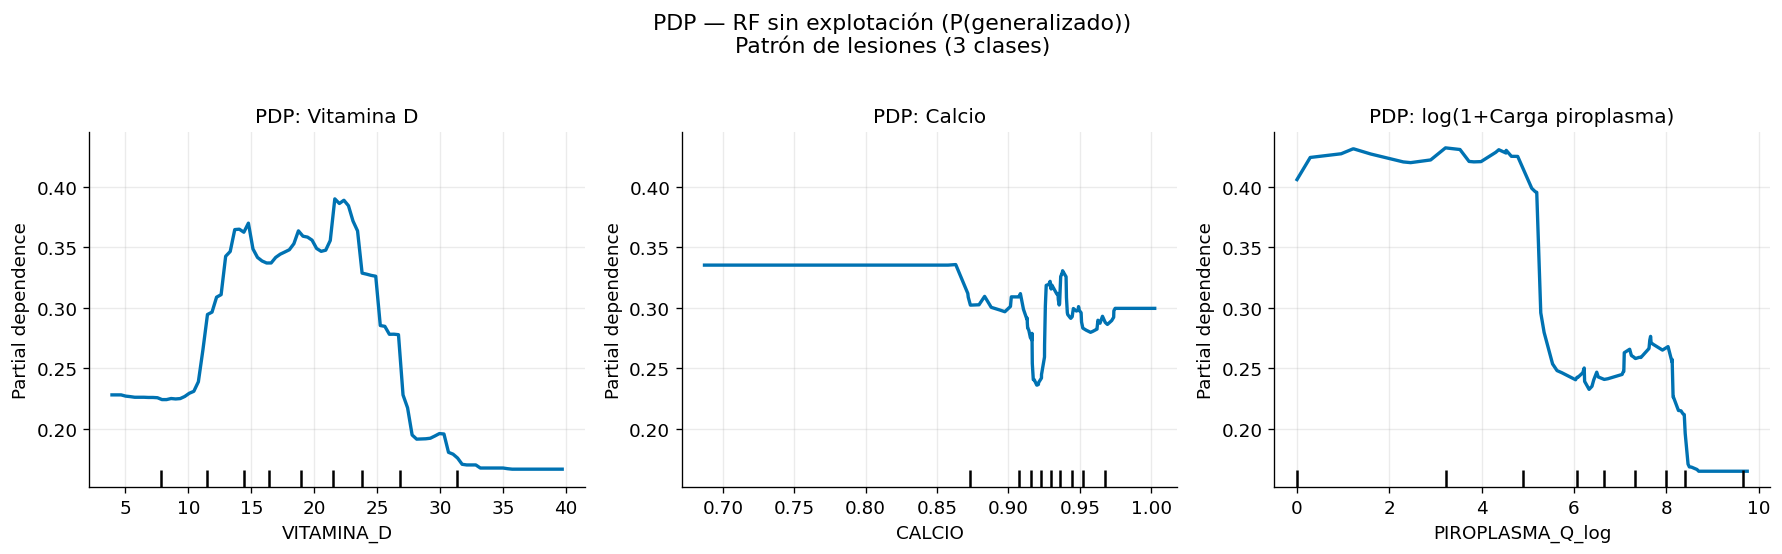

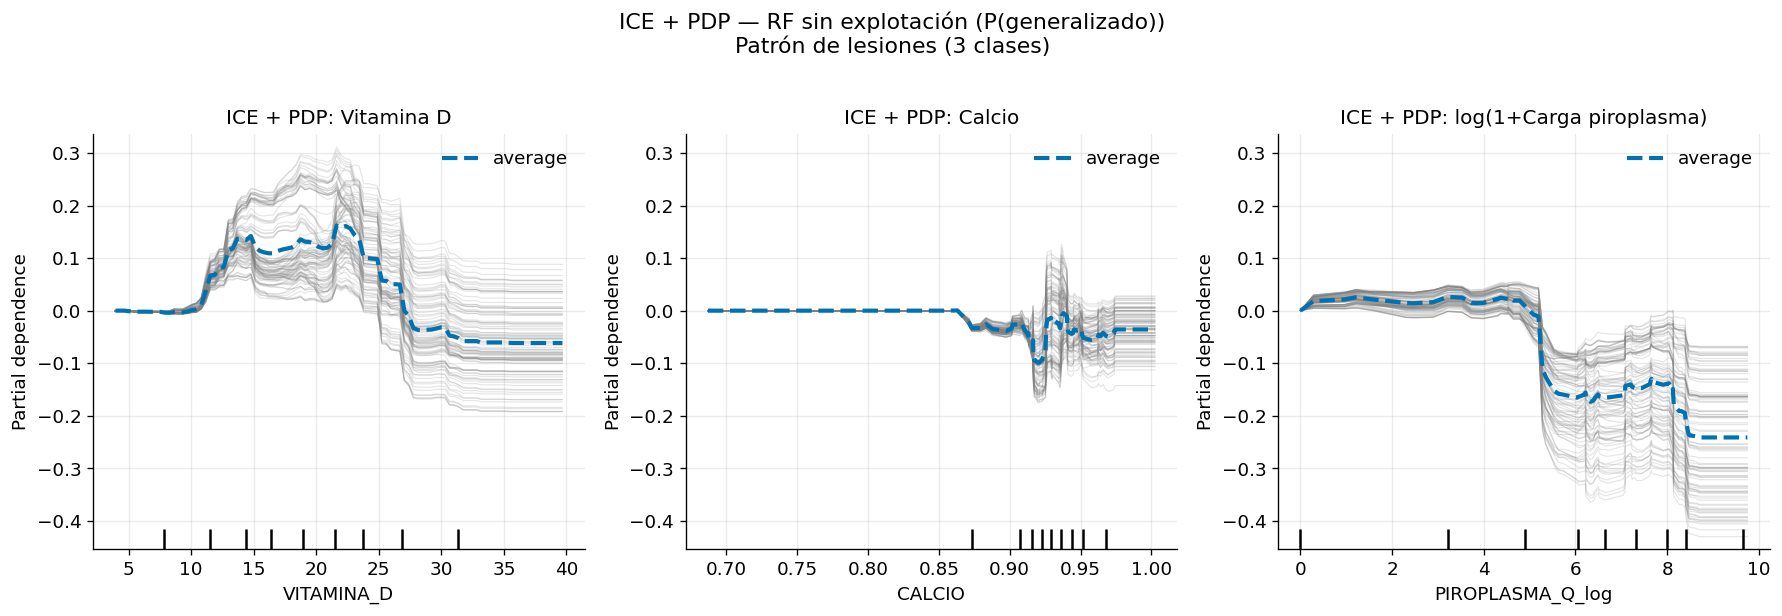

In [16]:
CONT_D = [f for f in SELECTED_D if f in tb.NUM_FEATURES and Xs[f].nunique() > 5]
if not CONT_D:
    CONT_D = [f for f in SELECTED_D if f in tb.NUM_FEATURES]

print(f"Features continuas para PDP/ICE: {CONT_D}")
if CONT_D:
    n_c = len(CONT_D)
    # PDP — target=1 especifica la clase "generalizado" para clasificadores multiclase
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4.5))
    if n_c == 1: axes = [axes]
    PartialDependenceDisplay.from_estimator(FINAL_D, Xs, CONT_D, kind="average",
        target=1, ax=axes, line_kw={"color": PALETTE[0], "lw": 2})
    for ax, f in zip(axes, CONT_D):
        ax.set_title(f"PDP: {tb.PRETTY.get(f, f)}")
    plt.suptitle("PDP — RF sin explotación (P(generalizado))\nPatrón de lesiones (3 clases)", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_2d_pdp.png", bbox_inches="tight"); plt.show()

    # ICE + PDP
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 5))
    if n_c == 1: axes = [axes]
    PartialDependenceDisplay.from_estimator(FINAL_D, Xs, CONT_D, kind="both",
        target=1, ax=axes,
        ice_lines_kw={"color": "grey", "alpha": 0.2, "lw": 0.7},
        pd_line_kw={"color": PALETTE[0], "lw": 2.5},
        centered=True)
    for ax, f in zip(axes, CONT_D):
        ax.set_title(f"ICE + PDP: {tb.PRETTY.get(f, f)}")
    plt.suptitle("ICE + PDP — RF sin explotación (P(generalizado))\nPatrón de lesiones (3 clases)", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_2d_ice.png", bbox_inches="tight"); plt.show()


## 7. Accumulated Local Effects (ALE)

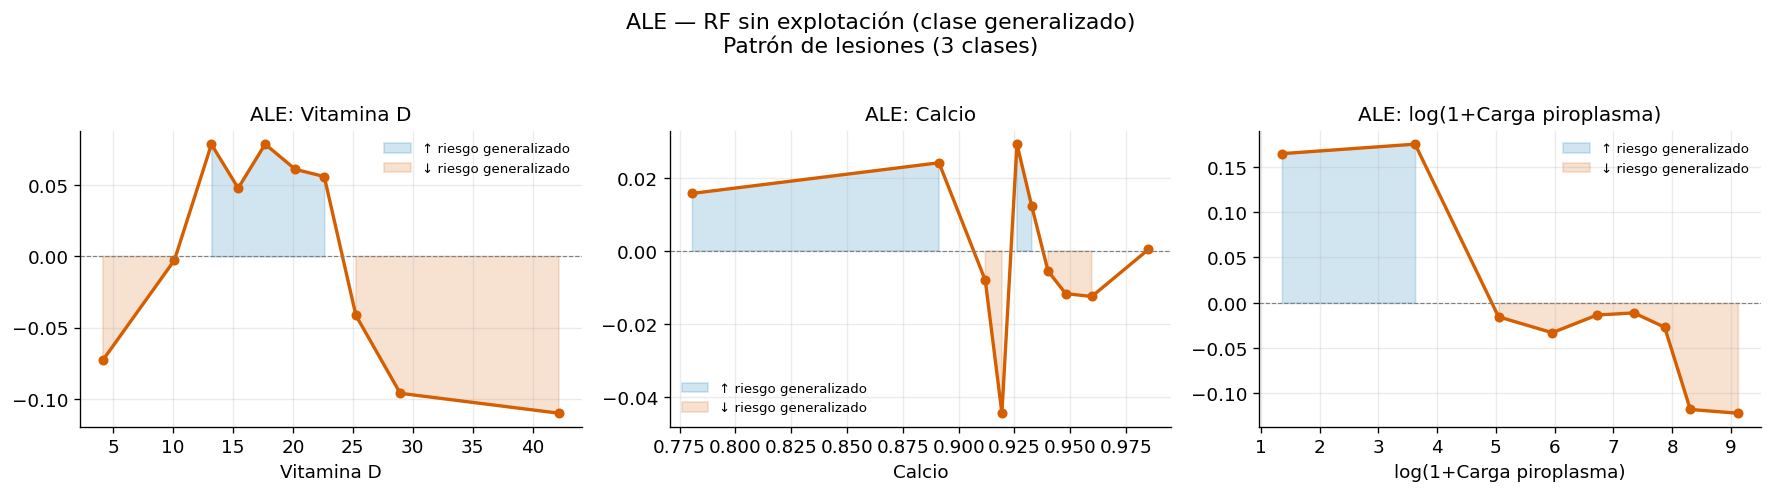

In [17]:
def ale_1d(model, X, feat, bins=10):
    x = X[feat].dropna().values
    q = np.quantile(x, np.linspace(0, 1, bins + 1)); q = np.unique(q)
    if len(q) < 3: return np.array([]), np.array([])
    eff, Xc = [], X.copy()
    for i in range(len(q) - 1):
        mask = (X[feat] >= q[i]) & (X[feat] <= q[i + 1])
        if mask.sum() == 0: eff.append(0.0); continue
        lo = Xc.loc[mask].copy(); lo[feat] = q[i]
        hi = Xc.loc[mask].copy(); hi[feat] = q[i + 1]
        eff.append((model.predict_proba(hi)[:, idx_gen] - model.predict_proba(lo)[:, idx_gen]).mean())
    ale = np.cumsum(eff); ale -= ale.mean()
    return (q[:-1] + q[1:]) / 2, ale

if CONT_D:
    n_c = len(CONT_D)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4))
    if n_c == 1: axes = [axes]
    for ax, feat in zip(axes, CONT_D):
        cx, ale = ale_1d(FINAL_D, Xs, feat)
        if len(cx) == 0: ax.set_title(f"ALE: {tb.PRETTY.get(feat,feat)}\n(insuf.)"); continue
        ax.plot(cx, ale, "o-", color=PALETTE[1], lw=2, ms=5)
        ax.axhline(0, color="grey", lw=0.7, ls="--")
        ax.fill_between(cx, 0, ale, where=(ale > 0), alpha=0.18, color=PALETTE[0], label="↑ riesgo generalizado")
        ax.fill_between(cx, 0, ale, where=(ale < 0), alpha=0.18, color=PALETTE[1], label="↓ riesgo generalizado")
        ax.set_title(f"ALE: {tb.PRETTY.get(feat,feat)}")
        ax.set_xlabel(tb.PRETTY.get(feat,feat)); ax.legend(fontsize=8)
    plt.suptitle("ALE — RF sin explotación (clase generalizado)\nPatrón de lesiones (3 clases)", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_2d_ale.png", bbox_inches="tight"); plt.show()

## 8. SHAP waterfall — interpretabilidad local

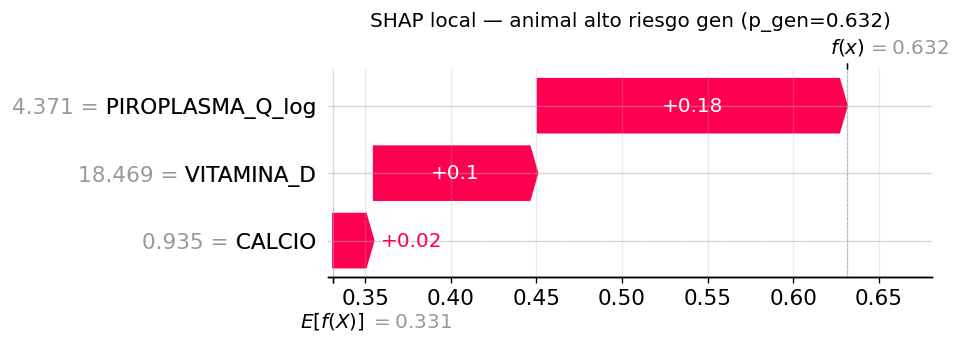

Animal 67: p_gen=0.632, clase real=1, pred=1


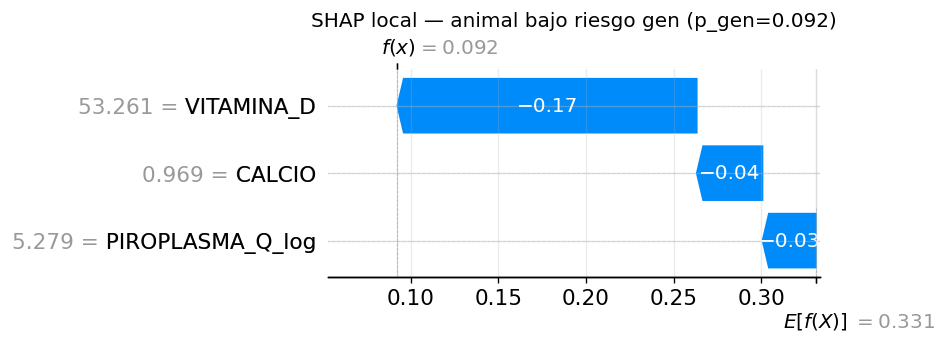

Animal 30: p_gen=0.092, clase real=-1, pred=-1


In [18]:
p_gen = FINAL_D.predict_proba(Xs)[:, idx_gen]
idx_pos = int(np.argmax(p_gen))
idx_neg = int(np.argmin(p_gen))

shap_exp_d = shap.Explanation(values=sv_d_gen, base_values=exp_val_d,
                               data=Xt_d, feature_names=names_d)

for tag, idx in [("alto_riesgo_gen", idx_pos), ("bajo_riesgo_gen", idx_neg)]:
    fig, _ = plt.subplots(figsize=(9, 4))
    shap.plots.waterfall(shap_exp_d[idx], max_display=len(names_d), show=False)
    plt.title(f"SHAP local — animal {tag.replace('_',' ')} (p_gen={p_gen[idx]:.3f})")
    plt.tight_layout()
    plt.savefig(f"figures/fig_2d_waterfall_{tag}.png", bbox_inches="tight"); plt.show()
    print(f"Animal {idx}: p_gen={p_gen[idx]:.3f}, clase real={y[idx]}, pred={FINAL_D.predict(Xs)[idx]}")

## 9. Contrafactuales

In [19]:
def find_cf(model, row_dict, feat, lo, hi, target_cls, n=500):
    for v in np.linspace(lo, hi, n):
        r = dict(row_dict); r[feat] = v
        if int(model.predict(pd.DataFrame([r]))[0]) == target_cls:
            return v
    return None

high_row = Xs.iloc[idx_pos].copy()
low_row  = Xs.iloc[idx_neg].copy()
target_cls = 1   # queremos predecir clase generalizado

print("=" * 60)
print("CONTRAFACTUALES — solo con biomarcadores (clase generalizado)")
print("=" * 60)
for tag, row, tgt in [("ALTO riesgo gen.", high_row, 0), ("BAJO riesgo gen.", low_row, target_cls)]:
    pred = int(FINAL_D.predict(pd.DataFrame([row]))[0])
    p    = FINAL_D.predict_proba(pd.DataFrame([row]))[0, idx_gen]
    print(f"\nAnimal {tag} (predicha={pred}, p_gen={p:.3f}), objetivo → clase {tgt}")
    for feat in CONT_D:
        lo_v, hi_v = float(Xs[feat].min()), float(Xs[feat].max())
        cf = find_cf(FINAL_D, row.to_dict(), feat, lo_v, hi_v, tgt)
        cur = row[feat]
        if cf is not None:
            print(f"  {tb.PRETTY.get(feat,feat):30s}: actual={cur:.2f} → cf={cf:.2f} (Δ={cf-cur:+.2f})")
        else:
            print(f"  {tb.PRETTY.get(feat,feat):30s}: actual={cur:.2f} → no alcanzable")

CONTRAFACTUALES — solo con biomarcadores (clase generalizado)

Animal ALTO riesgo gen. (predicha=1, p_gen=0.632), objetivo → clase 0
  Vitamina D                    : actual=18.47 → cf=0.08 (Δ=-18.39)
  Calcio                        : actual=0.93 → no alcanzable
  log(1+Carga piroplasma)       : actual=4.37 → cf=5.28 (Δ=+0.91)

Animal BAJO riesgo gen. (predicha=-1, p_gen=0.092), objetivo → clase 1
  Vitamina D                    : actual=53.26 → cf=13.29 (Δ=-39.97)
  Calcio                        : actual=0.97 → no alcanzable
  log(1+Carga piroplasma)       : actual=5.28 → no alcanzable


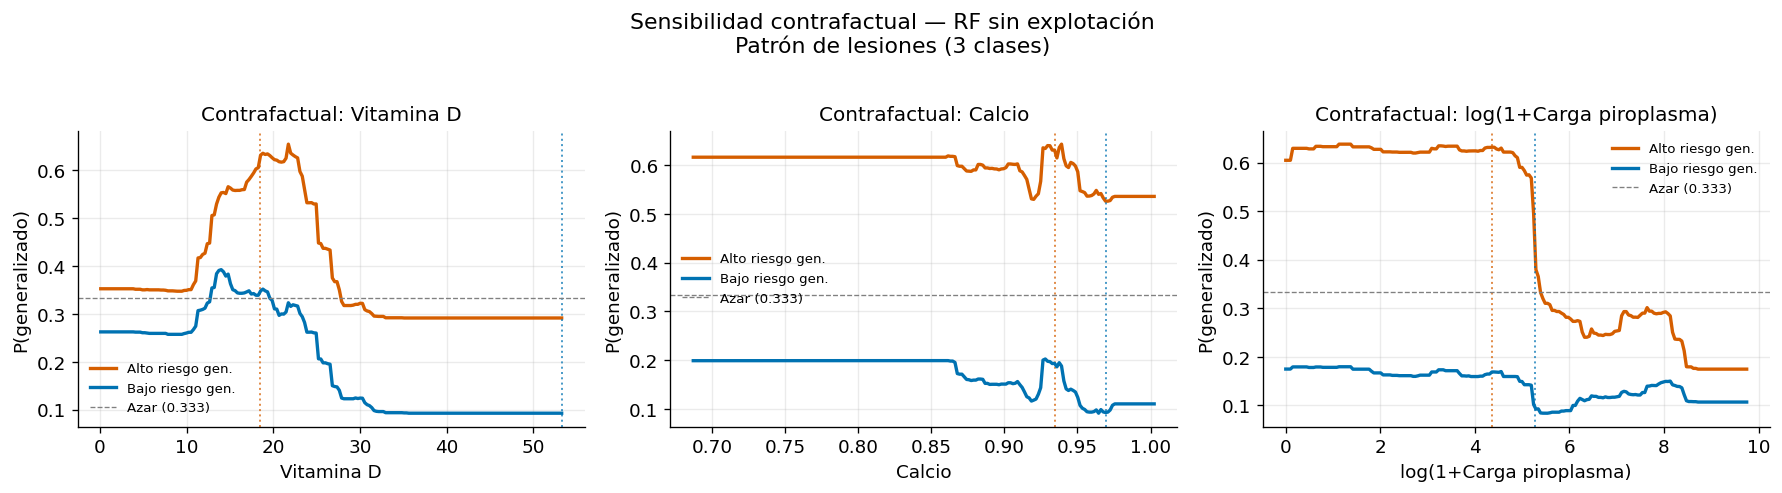

In [20]:
if CONT_D:
    n_c = len(CONT_D)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4))
    if n_c == 1: axes = [axes]
    for ax, feat in zip(axes, CONT_D):
        lo_v, hi_v = float(Xs[feat].min()), float(Xs[feat].max())
        grid = np.linspace(lo_v, hi_v, 200)
        for tag, row, color in [("Alto riesgo gen.", high_row, PALETTE[1]), ("Bajo riesgo gen.", low_row, PALETTE[0])]:
            probs = [FINAL_D.predict_proba(pd.DataFrame([{**row.to_dict(), feat: v}]))[0, idx_gen] for v in grid]
            ax.plot(grid, probs, color=color, lw=2, label=tag)
            ax.axvline(row[feat], color=color, ls=":", lw=1.2, alpha=0.7)
        ax.axhline(1/3, color="grey", ls="--", lw=0.8, label="Azar (0.333)")
        ax.set_xlabel(tb.PRETTY.get(feat, feat))
        ax.set_ylabel("P(generalizado)")
        ax.set_title(f"Contrafactual: {tb.PRETTY.get(feat,feat)}"); ax.legend(fontsize=8)
    plt.suptitle("Sensibilidad contrafactual — RF sin explotación\nPatrón de lesiones (3 clases)", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_2d_cf_curves.png", bbox_inches="tight"); plt.show()

## 10. Síntesis y triangulación

### Tabla comparativa (rellenar con resultados de los notebooks)

| Métrica | Nb 2 — LOFO | Nb 2b — CV + expl | Nb 2c — CV sin expl (TB) | **Nb 2d — CV sin expl (3 cls)** |
|---|---|---|---|---|
| BAL_ACC / PR-AUC | — | — | — | **—** |
| ROC-AUC | — | — | — | **—** |
| Target | Lesiones_TB | Lesiones_TB | Lesiones_TB | **Patron_lesiones_3** |
| CV strategy | Leave-One-Farm-Out | RepeatedSKFold | RepeatedSKFold | **RepeatedSKFold** |
| Expl como feature | No | Sí | No | **No** |
| N clases | 2 | 2 | 2 | **3** |

### Guía de interpretación

- **Si BAL_ACC(2d) >> 0.333:** existe señal predictiva de los biomarcadores para diferenciar
  entre sin lesión, localizado y generalizado.

- **Si BAL_ACC(2d) ≈ 0.333:** los biomarcadores disponibles no discriminan entre los tres
  patrones lesionales. Ello puede reflejar limitaciones del tamaño muestral, solapamiento
  biológico entre clases, o confusión por efectos de granja.

- **BAL_ACC vs ROC-AUC macro:** en clases muy desbalanceadas, BAL_ACC es más conservador;
  ROC-AUC macro puede ser más optimista. Ambas métricas se reportan para triangulación.

### Implicaciones clínicas
La clase **generalizado** (1) representa el mayor compromiso sistémico de la infección.
Los SHAP para esta clase y los contrafactuales indican qué cambios en biomarcadores
estarían asociados a mayor o menor riesgo de lesión generalizada.